## Task 1: Preprocessing

Image shape: (256, 256)
Min pixel value: 0.0
Max pixel value: 254.21023530914124


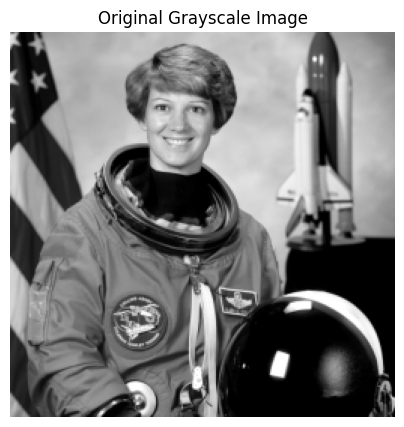

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

img_color = data.astronaut()
img_gray = color.rgb2gray(img_color)

img_gray = resize(img_gray, (256, 256), anti_aliasing=True)

# Scale to 0-255 range
img_gray = (img_gray * 255).astype(np.float64)

print("Image shape:", img_gray.shape)
print("Min pixel value:", img_gray.min())
print("Max pixel value:", img_gray.max())

plt.figure(figsize=(5,5))
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

I used the built-in astronaut image from skimage. I converted it to grayscale and resized it to 256x256 so that it can be evenly divided into 8x8 blocks (256 / 8 = 32 blocks per row/column).

## Task 2: Block-wise SVD Function

In [2]:
def compress_block(block, k):
    """
    Takes an 8x8 block and reconstructs it using only the top-k singular values.
    """
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    
    # Keep only top-k
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    # Reconstruct the block
    reconstructed = U_k @ np.diag(S_k) @ Vt_k
    return reconstructed


def compress_image(image, k, block_size=8):
    """
    Splits the image into blocks, compresses each block with rank-k SVD,
    then puts the image back together.
    """
    h, w = image.shape
    result = np.zeros_like(image)
    
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = image[i:i+block_size, j:j+block_size]
            result[i:i+block_size, j:j+block_size] = compress_block(block, k)
    
    return result

The `compress_block` function applies SVD to a single 8x8 block and reconstructs it using only the top-k components. The `compress_image` function just loops through all the blocks in the image and applies `compress_block` on each one, then puts everything back together.

## Task 3: Compression Analysis

In [3]:
block_size = 8
original_per_block = block_size * block_size  # 64 values

k_values = list(range(1, 9))
compression_ratios = []
frobenius_errors = []
compressed_images = []

for k in k_values:
    compressed = compress_image(img_gray, k)
    compressed_images.append(compressed)
    
    retained_per_block = k * (block_size + block_size + 1)  # k*(8+8+1)
    cr = original_per_block / retained_per_block
    compression_ratios.append(cr)
    
    error = np.linalg.norm(img_gray - compressed, 'fro')
    frobenius_errors.append(error)
    
    print(f"k={k} | Compression Ratio: {cr:.3f} | Frobenius Error: {error:.2f}")

k=1 | Compression Ratio: 3.765 | Frobenius Error: 3570.24
k=2 | Compression Ratio: 1.882 | Frobenius Error: 1765.86
k=3 | Compression Ratio: 1.255 | Frobenius Error: 909.14
k=4 | Compression Ratio: 0.941 | Frobenius Error: 499.19
k=5 | Compression Ratio: 0.753 | Frobenius Error: 270.38
k=6 | Compression Ratio: 0.627 | Frobenius Error: 128.05
k=7 | Compression Ratio: 0.538 | Frobenius Error: 35.54
k=8 | Compression Ratio: 0.471 | Frobenius Error: 0.00


For each k, the compression ratio is calculated as:

    Compression Ratio = 64 / (k * 17)

Because each 8x8 block has 64 original values, and with rank-k SVD we only store k*(8+8+1) = 17k values. A ratio > 1 means we're actually compressing. The Frobenius norm measures how different the reconstructed image is from the original.

## Task 4: Visualizations

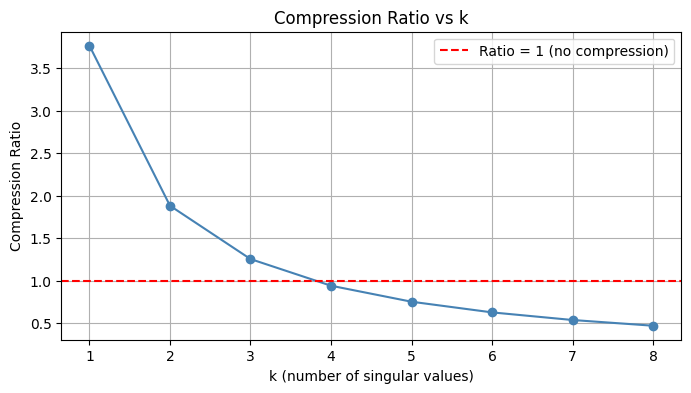

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, compression_ratios, marker='o', color='steelblue')
plt.xlabel('k (number of singular values)')
plt.ylabel('Compression Ratio')
plt.title('Compression Ratio vs k')
plt.axhline(y=1, color='red', linestyle='--', label='Ratio = 1 (no compression)')
plt.legend()
plt.grid(True)
plt.show()

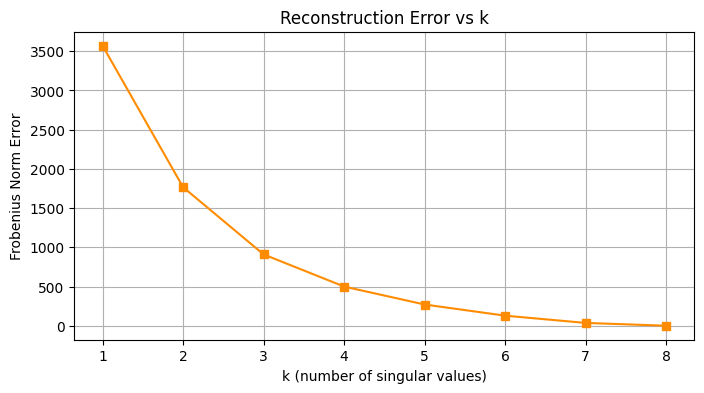

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, frobenius_errors, marker='s', color='darkorange')
plt.xlabel('k (number of singular values)')
plt.ylabel('Frobenius Norm Error')
plt.title('Reconstruction Error vs k')
plt.grid(True)
plt.show()

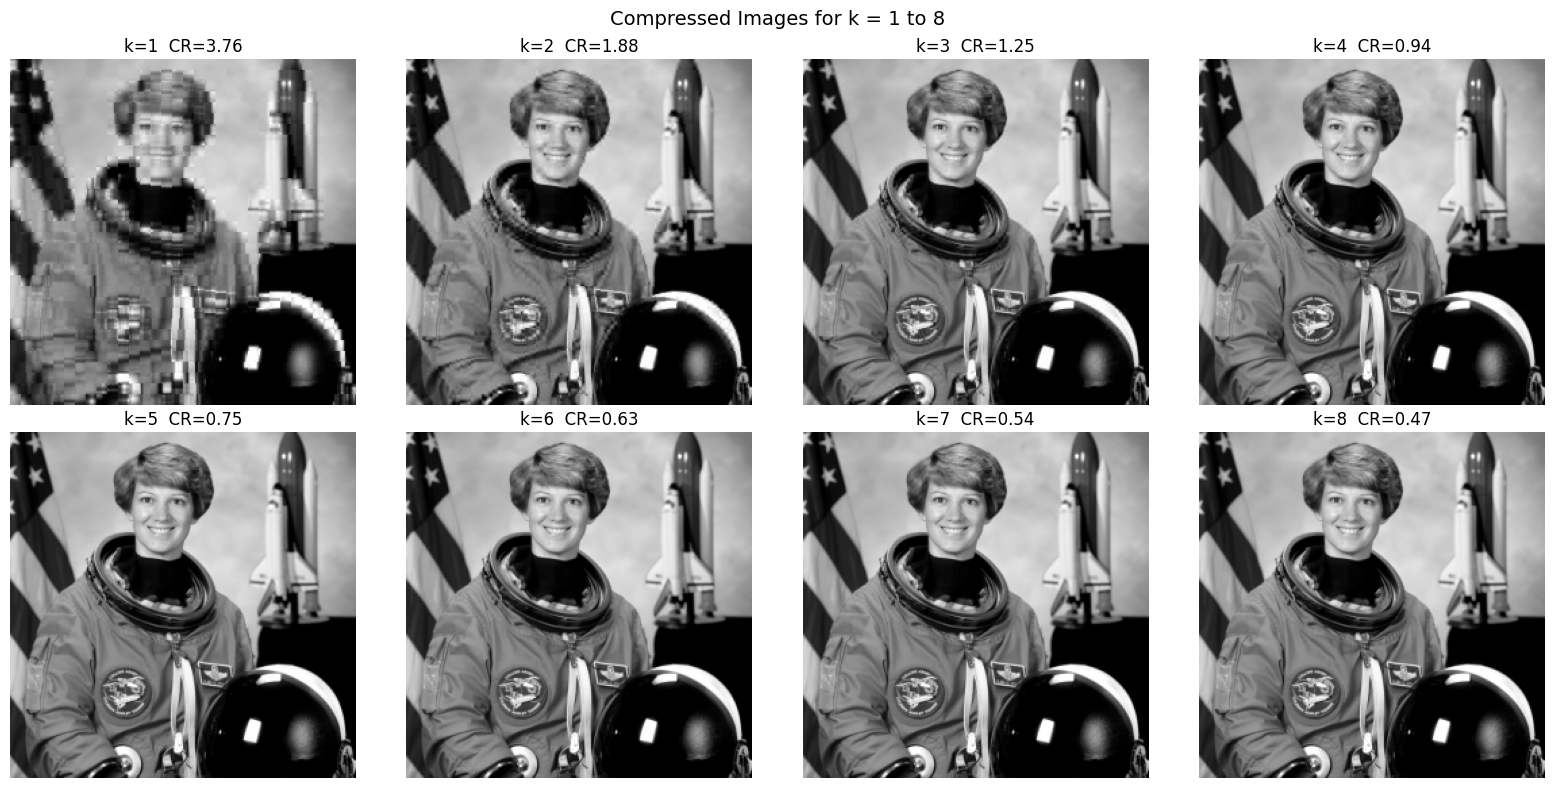

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    axes[idx].imshow(np.clip(compressed_images[idx], 0, 255), cmap='gray')
    axes[idx].set_title(f'k={k}  CR={compression_ratios[idx]:.2f}')
    axes[idx].axis('off')

plt.suptitle('Compressed Images for k = 1 to 8', fontsize=14)
plt.tight_layout()
plt.show()

The first plot shows that as k increases, the compression ratio drops because we're storing more data per block. When k=1, we have the highest compression but worst quality. When k=8, the ratio is close to 1 meaning basically no compression.

The second plot shows the error going down as k increases, which makes sense because we're keeping more information from each block.

Looking at the reconstructed images, k=1 looks super blurry and blocky. By around k=4 or 5 the image starts to look pretty decent.

## Task 5-1: PSNR (Peak Signal-to-Noise Ratio)

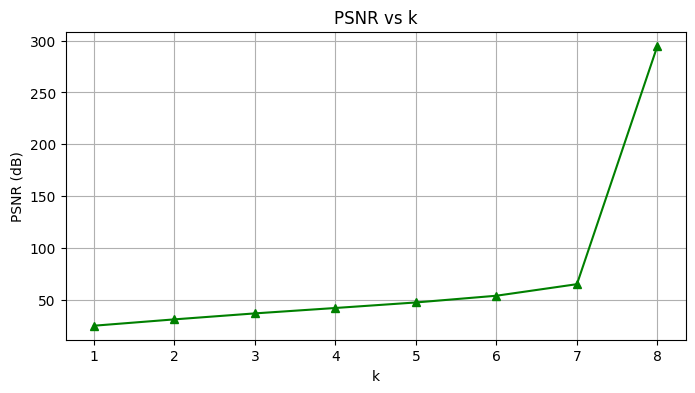

k     CR         Frob Error      PSNR (dB) 
----------------------------------------
1     3.765      3570.24         25.24     
2     1.882      1765.86         31.36     
3     1.255      909.14          37.12     
4     0.941      499.19          42.33     
5     0.753      270.38          47.66     
6     0.627      128.05          54.15     
7     0.538      35.54           65.28     
8     0.471      0.00            295.06    


In [7]:
def compute_psnr(original, reconstructed, max_val=255.0):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 20 * np.log10(max_val / np.sqrt(mse))
    return psnr

psnr_values = [compute_psnr(img_gray, comp) for comp in compressed_images]

plt.figure(figsize=(8, 4))
plt.plot(k_values, psnr_values, marker='^', color='green')
plt.xlabel('k')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs k')
plt.grid(True)
plt.show()

print(f"{'k':<5} {'CR':<10} {'Frob Error':<15} {'PSNR (dB)':<10}")
print("-" * 40)
for i, k in enumerate(k_values):
    print(f"{k:<5} {compression_ratios[i]:<10.3f} {frobenius_errors[i]:<15.2f} {psnr_values[i]:<10.2f}")

PSNR is another way to measure image quality. Higher PSNR = better quality. Generally, a PSNR above 30 dB is considered acceptable for most images. We can see that as k increases, PSNR goes up because the reconstruction is closer to the original.

## Task 5-2: Try Different Block Sizes

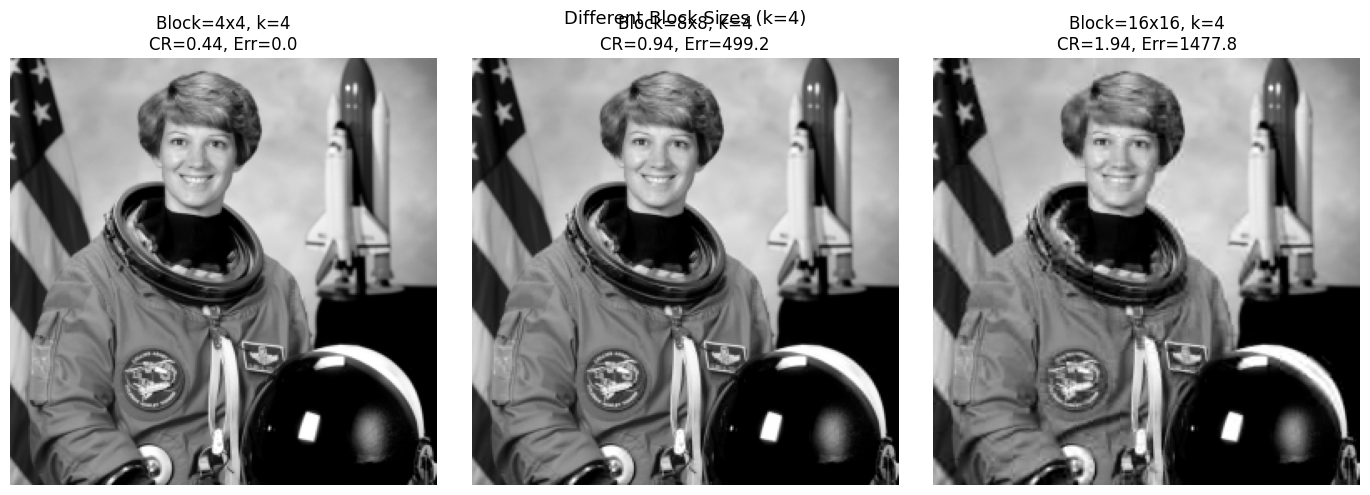

In [8]:
block_sizes = [4, 8, 16]
k_fixed = 4

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, bs in enumerate(block_sizes):
    compressed = compress_image(img_gray, k=min(k_fixed, bs), block_size=bs)
    
    original_vals = bs * bs
    retained_vals = min(k_fixed, bs) * (bs + bs + 1)
    cr = original_vals / retained_vals
    error = np.linalg.norm(img_gray - compressed, 'fro')
    
    axes[idx].imshow(np.clip(compressed, 0, 255), cmap='gray')
    axes[idx].set_title(f'Block={bs}x{bs}, k={min(k_fixed,bs)}\nCR={cr:.2f}, Err={error:.1f}')
    axes[idx].axis('off')

plt.suptitle('Different Block Sizes (k=4)', fontsize=13)
plt.tight_layout()
plt.show()

When using smaller blocks (4x4), the compression ratio is lower but the image tends to look sharper because each block captures a smaller local area. Larger blocks (16x16) give higher compression ratios but can introduce more visible artifacts. The 8x8 block size is a good middle ground, which is also why JPEG uses it.

## Summary

- A smaller k means higher compression but worse image quality. A larger k means better quality but less compression.
- At k=1 we get the highest compression ratio (around 3.76x for 8x8 blocks) but the image looks very blurry.
- At k=8, the compression ratio drops below 1, meaning it's actually less efficient than just storing the original block.
- The sweet spot seems to be around k=3 to k=5 where you get decent quality with meaningful compression.
- PSNR confirms this trend, values improve a lot from k=1 to k=5 but slow down after that.
- Different block sizes also affect the tradeoff. Smaller blocks = more detail preserved but less compression gain.